In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os
import sys
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import src.raw_preprocessing as rp
import src.feature_engineering as fe

### We'll analyse our data

In [3]:
df = pd.read_parquet("../data/final_datasets/datasets_tree_based_models/conso_v1_tree.parquet")

Text(0.5, 0, 'Time (30 min)')

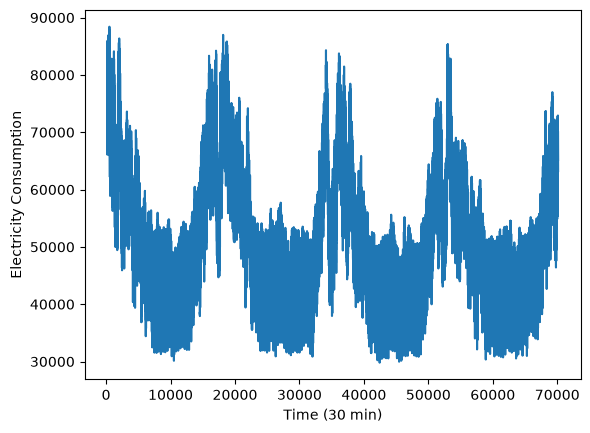

In [4]:
plt.figure()
plt.plot(df['Consommation'])
plt.ylabel('Electricity Consumption')
plt.xlabel('Time (30 min)')

We can observe a repeating cycle each year.
Let's zom in the chart to analyse the pattern during one year.

In [5]:
df.columns

Index(['Consommation', 'Zone_A', 'Zone_B', 'Zone_C',
       'Vacances de la Toussaint', 'Vacances de Noël', 'Vacances d'Hiver',
       'Vacances de Printemps', 'Vacances d'Été', 'public_holidays', '44T',
       '69T', '31T', '21T', '59T', '75T', '13T', '35T', '67T', '45T', '76T',
       '33T', 'T', 'U', 'FF', 'PMER', 'RR1', 'year', 'month', 'hour',
       'day_of_week', 'is_weekend', 'lagged_1', 'lagged_24', 'lagged_48',
       'lagged_168', 'hour_sin', 'hour_cos', 'day_of_week_sin',
       'day_of_week_cos', 'month_sin', 'month_cos', 'rolling_mean_24h',
       'rolling_std_24h', 'rolling_mean_7d', 'rolling_max_24h',
       'rolling_min_24h', 'consumption_diff_1', 'consumption_diff_48',
       'consumption_pct_change_1', 'consumption_pct_change_48',
       'season_Autumn', 'season_Spring', 'season_Summer', 'season_Winter',
       'temp_sq', 'temp_x_humidity', 'temp_x_wind', 'hour_x_is_weekend',
       'hour_x_is_holiday'],
      dtype='str')

In [6]:
months = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

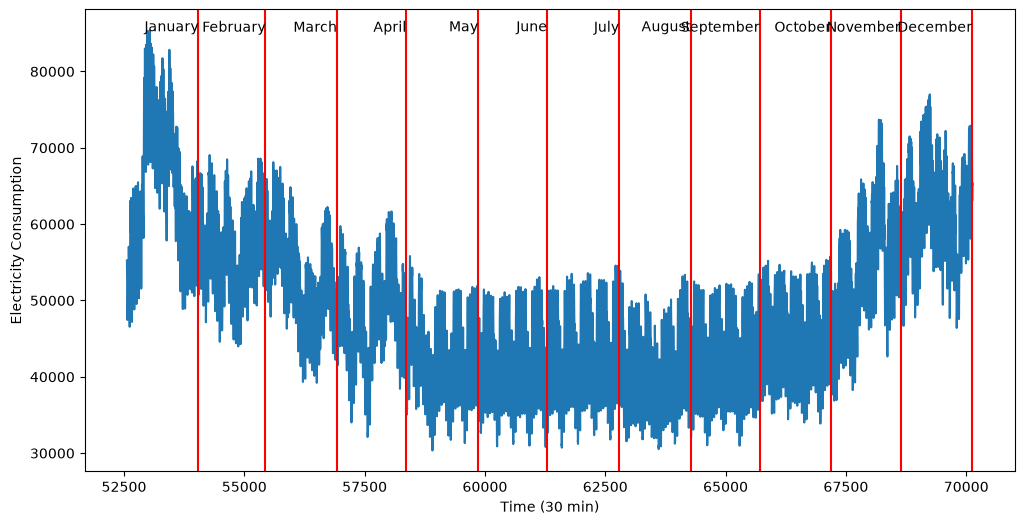

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df[df['year']==2024]['Consommation'])
plt.ylabel('Electricity Consumption')
plt.xlabel('Time (30 min)')

for i in range(1, 13):
    subset = df[(df['year'] == 2024) & (df['month'] == i)]
    line = subset.index[-1]
    plt.axvline(line, c='red')
    y_pos = df['Consommation'].max()*0.98
    
    plt.text(line, y_pos, months[subset['month'].unique()[0]], rotation=0, va='top', ha='right')

We can observe that electricity consumption is higher during winter than summer.  
As soon as the temperature starts to drop, the electricity consumption goes up.  
During summer and autumn, the electricty consumption evolves between a gap (between 30'000 MW and 50'000 MW)

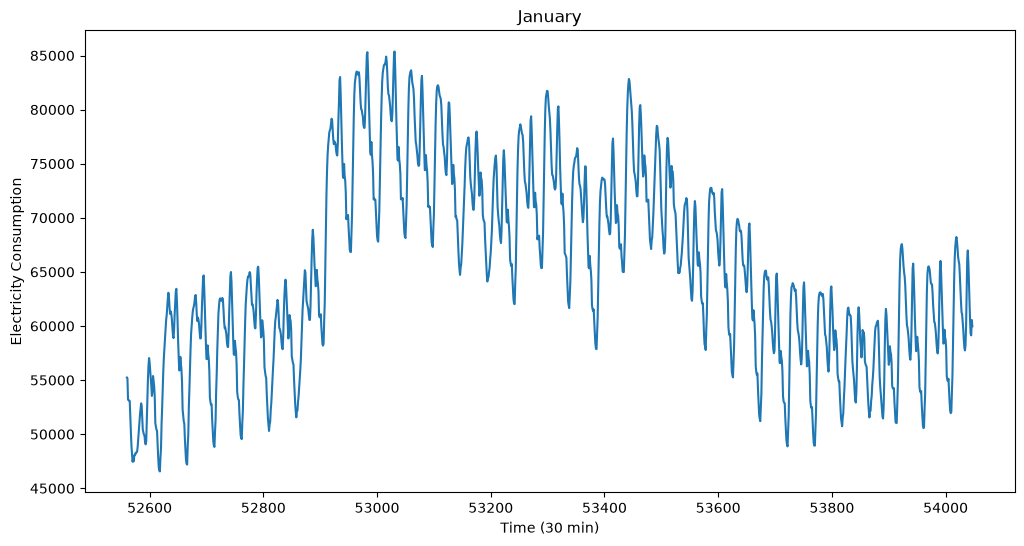

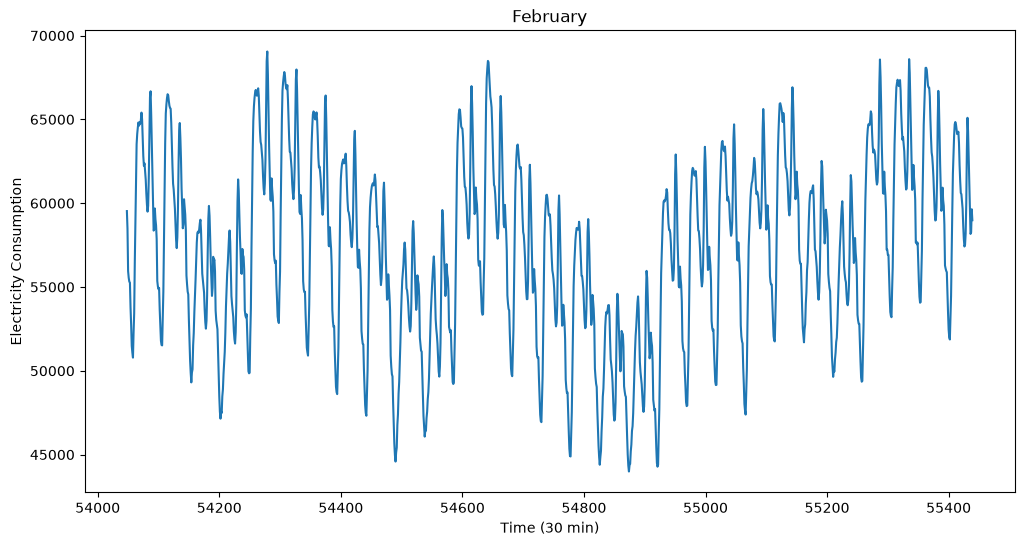

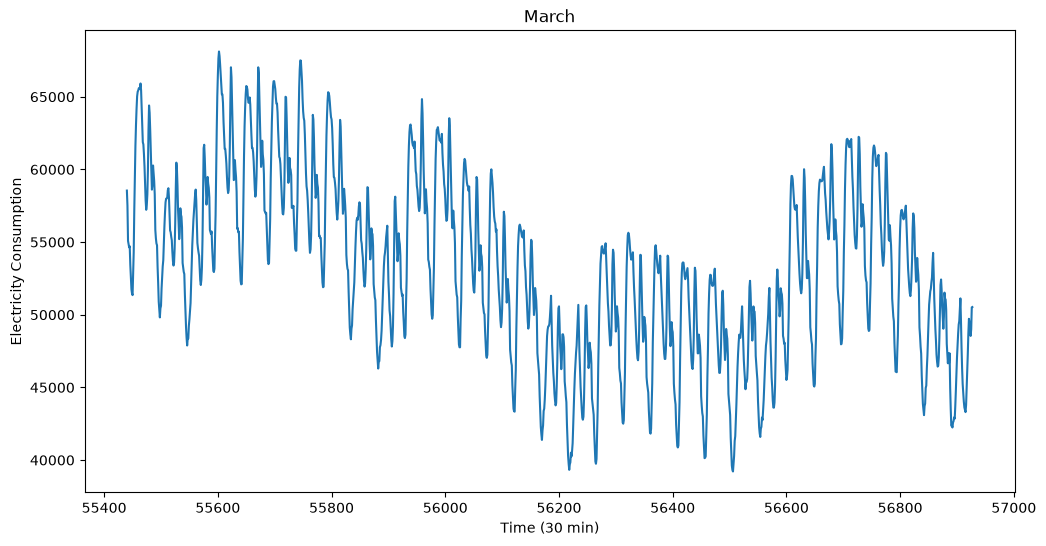

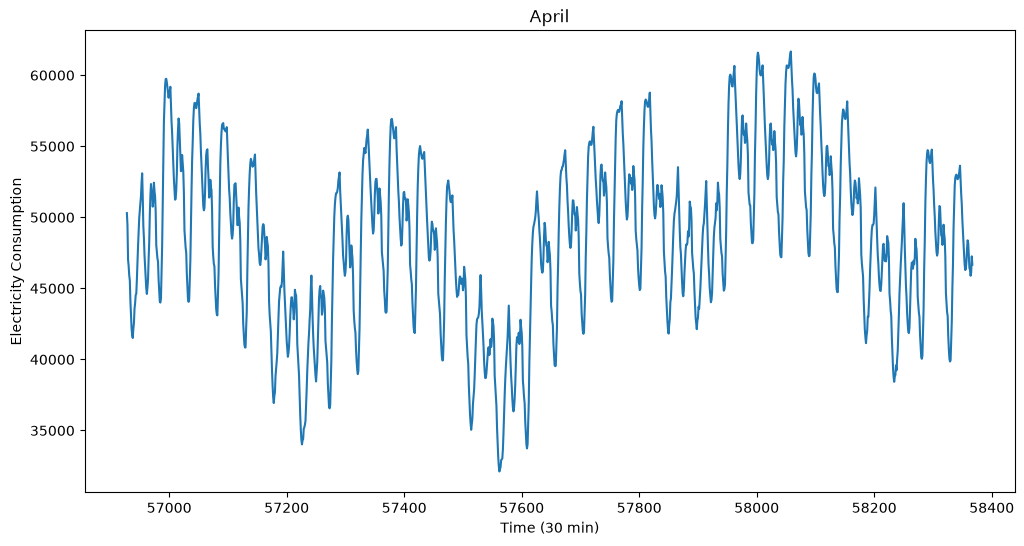

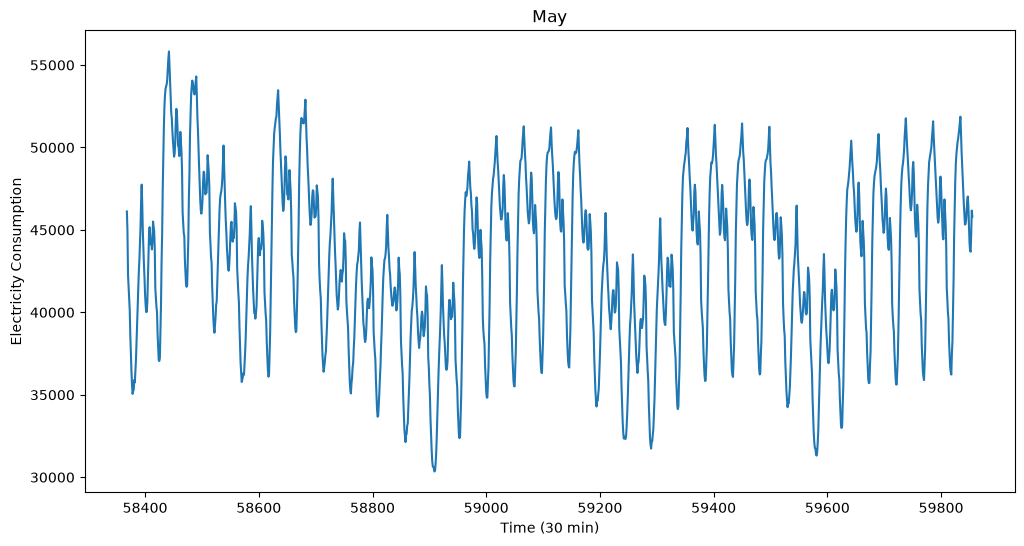

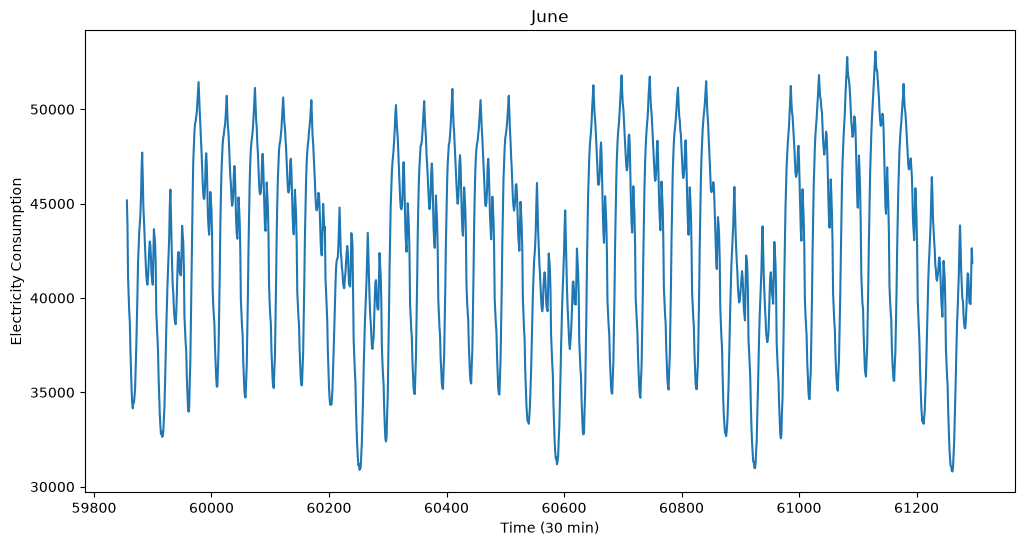

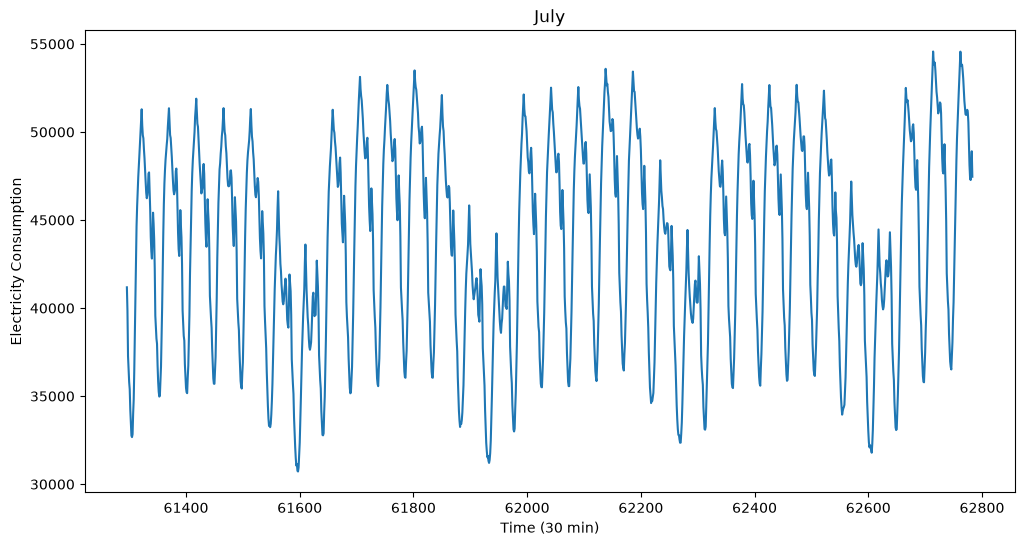

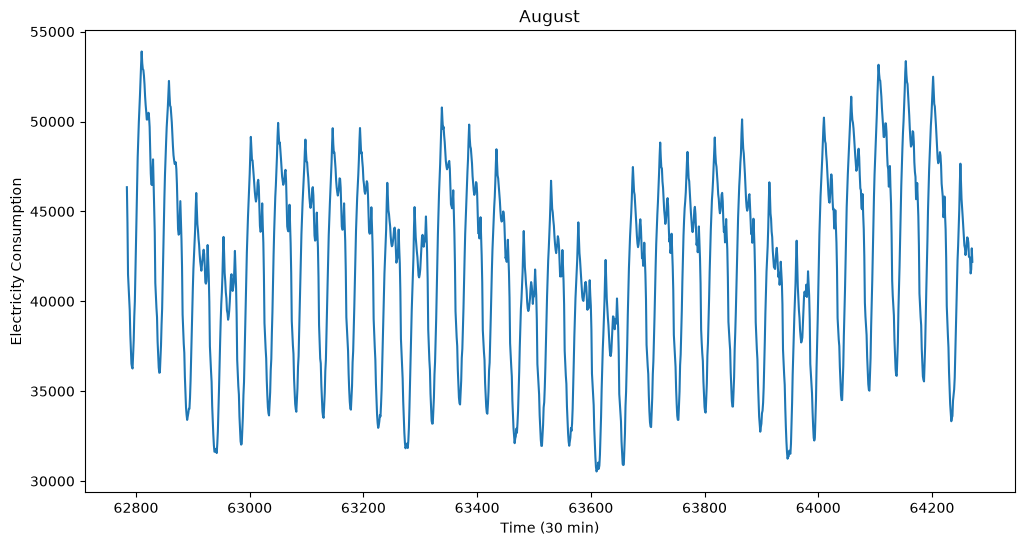

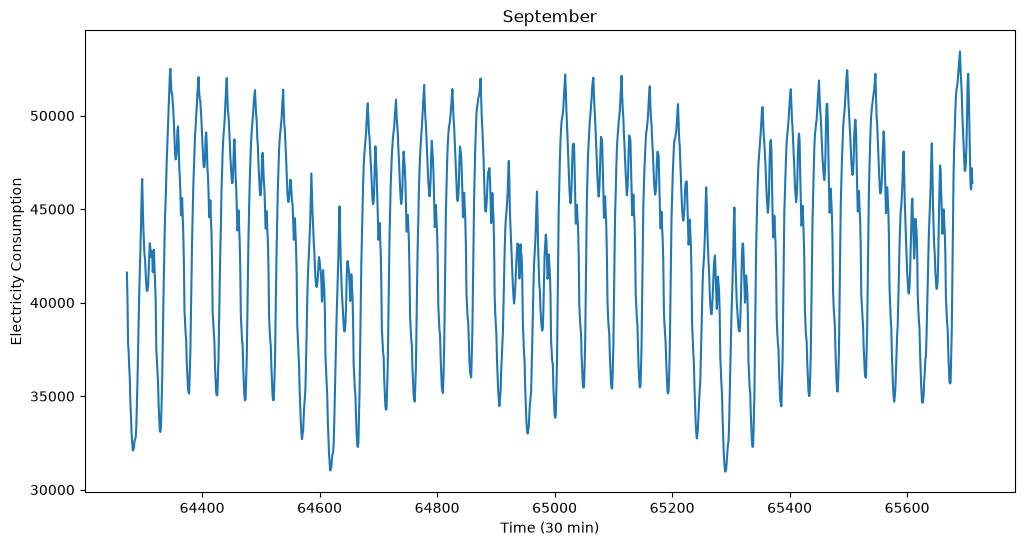

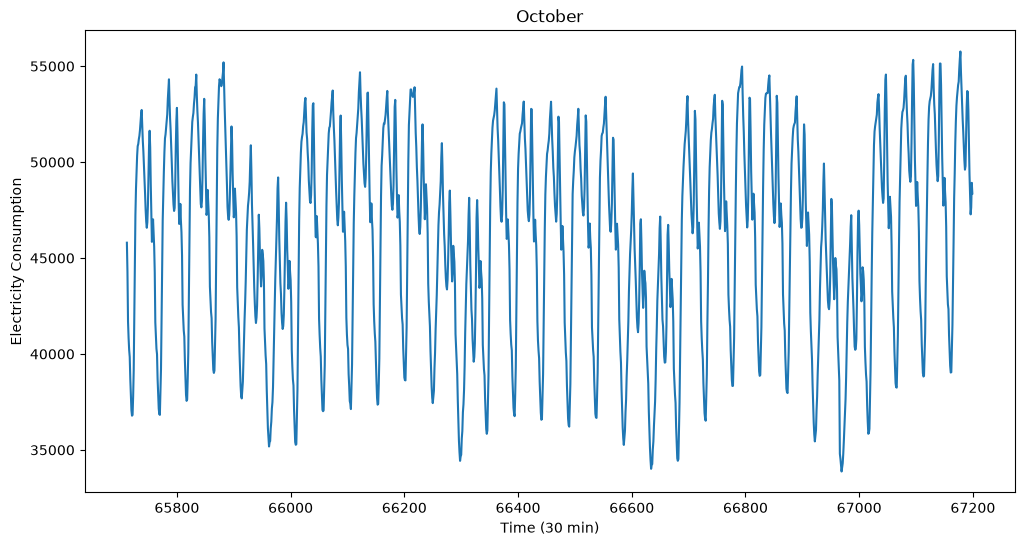

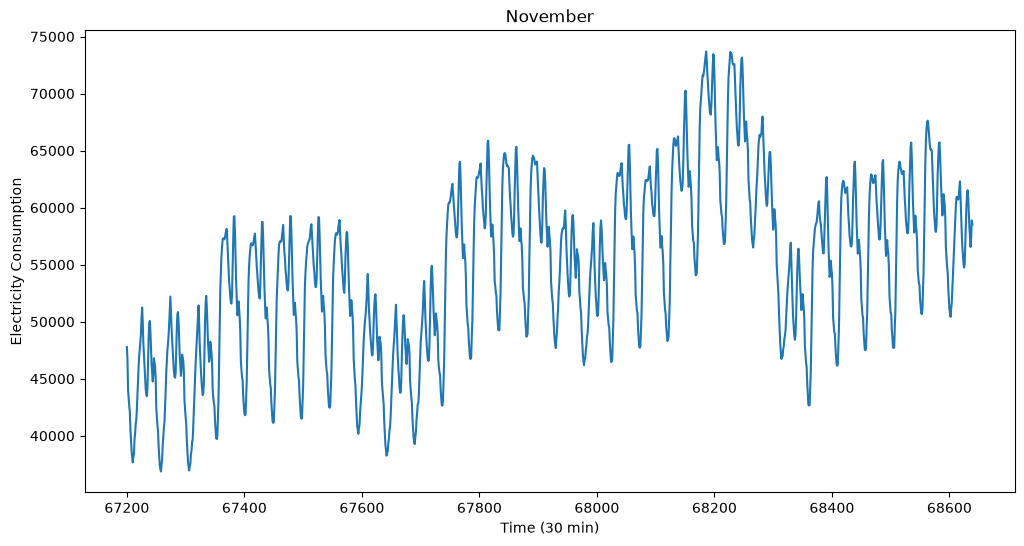

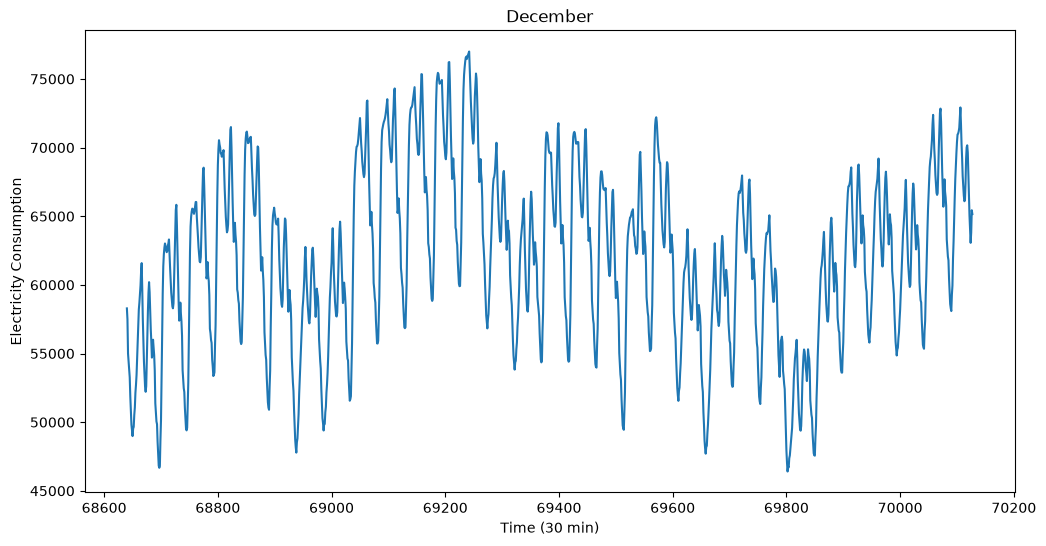

In [8]:
for i in range(1, 13):

    subset = df[(df['year'] == 2024) & (df['month'] == i)]
    
    plt.figure(figsize=(12, 6))
    plt.plot(subset[subset['year']==2024]['Consommation'])
    plt.title(months[subset['month'].unique()[0]])
    plt.ylabel('Electricity Consumption')
    plt.xlabel('Time (30 min)')


On every chart we can observe a repeating pattern throughout each week of the month and also a repeating pattern throughout each days, which means that the features that provides us informations about the day are very important.

### Feature selection  
We are going to select the most important features for the best datasets